### NumPy Hands-on Lab: From Arrays to Image Analysis

## Student Practice Notebook

**Name:** Aastha Kirtania  
**Register Number:** AP24110010038
**Date:** 07th August 2026

## Learning Objectives

After completing this lab, you will be able to:

- Create and manipulate NumPy arrays
- Understand array properties and dimensions
- Perform indexing and slicing
- Apply mathematical operations
- Understand and explain broadcasting
- Analyze images using NumPy arrays
- Perform basic image transformations
- Explain *why* NumPy is used in real ML/Data Science pipelines, not just *how*

### How to use this notebook
- **Demonstration** cells: run them, read the output, understand it.
- **Practice** cells: write your own code — don't copy the demo verbatim.
- **Predict-then-run**: before running some cells, you'll be asked to *predict* the output first. Write your prediction in the markdown cell, then run and compare.
- **Reflection**: short written answers, in your own words.


## Part 1: Introduction to NumPy

NumPy (Numerical Python) is a Python library used for efficient numerical computation.

**Why not just use Python lists?** Python lists store objects with overhead per element and loop in pure Python. NumPy arrays store raw numbers in contiguous memory and use compiled C code for operations — this is called **vectorization**. That's why NumPy is used everywhere in:

- Data Science (pandas is built on NumPy)
- Machine Learning (feeding data into models as arrays/tensors)
- Image Processing (an image *is* a NumPy array)
- Scientific Computing

Let's actually *see* the speed difference before we take it on faith.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy is ready!")


NumPy is ready!


### Demonstration: Loops vs. Vectorization (the "why" behind NumPy)

Below we add 1 to a million numbers two ways: a plain Python loop, and a NumPy array operation.
Run this cell and look at the timing output.


In [ ]:
import time

n = 1_000_000
python_list = list(range(n))
numpy_array = np.arange(n)

start = time.time()
result_list = [x + 1 for x in python_list]
loop_time = time.time() - start

start = time.time()
result_array = numpy_array + 1
vector_time = time.time() - start

print(f"Python loop time : {loop_time:.5f} seconds")
print(f"NumPy vector time: {vector_time:.5f} seconds")
print(f"NumPy was about {loop_time/vector_time:.0f}x faster")


Python loop time : 0.05361 seconds
NumPy vector time: 0.00412 seconds
NumPy was about 13x faster


**Reflection (write your answer):** Based on the timing above, in your own words, why is NumPy faster than a Python loop for this kind of operation?

*Your answer: NumPy is faster because it processes entire arrays at once using optimized code, instead of iterating through elements individually like Python loops.

## Part 2: Creating NumPy Arrays

### Demonstration

In [ ]:
arr = np.array([10,20,30,40,50])
arr


array([10, 20, 30, 40, 50])

### Student Practice

Create an array containing:

5, 10, 15, 20, 25

Write your code below (do not just copy the demo — change the numbers yourself):


In [ ]:
# Write your answer here
arr = np.array([5,10,15,20,25])
arr


array([ 5, 10, 15, 20, 25])

## Part 3: Array Properties

Important properties:

- `ndim` : Number of dimensions
- `shape` : Size of each dimension
- `size` : Total number of elements
- `dtype` : Data type

**Predict first:** for the array `arr` from Part 2, what do you *expect* `ndim`, `shape`, `size`, and `dtype` to be? Write your guess below before running the next cell.

*Your prediction:*
ndim: 1
shape: 5
size: 5
dtype: int64

In [ ]:
arr.ndim, arr.shape, arr.size, arr.dtype


(1, (5,), 5, dtype('int64'))

### Observation

Was your prediction correct? If not, what did you get wrong and why?

Dimension:

Shape: haven't learnt

Size:

Data Type:


## Part 4: Special Arrays

These are commonly used to initialize data — for example, `zeros` is often used to create an empty "canvas" array before filling in real values (you'll see this again in the image section).


In [ ]:
np.zeros((3,3))


array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [ ]:
np.ones((4,4))


array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [ ]:
np.eye(3)


array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### Student Practice

Create a `5x5` array of all zeros, and a `2x6` array of all ones. Write both below.


In [ ]:
# Write your answer here
#np.zeros((5,5))
np.ones((2,6))

array([[1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1.]])

## Part 5: Sequence Generation

In [ ]:
np.arange(0,50,5)


array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45])

In [ ]:
np.linspace(0,100,10)


array([  0.        ,  11.11111111,  22.22222222,  33.33333333,
        44.44444444,  55.55555556,  66.66666667,  77.77777778,
        88.88888889, 100.        ])

### Student Practice

`np.arange` and `np.linspace` both generate sequences but work differently.

1. Use `np.arange` to generate even numbers from 2 to 20.
2. Use `np.linspace` to generate 5 evenly spaced numbers between 0 and 1.
3. In one sentence, write the difference between `arange` (step-based) and `linspace` (count-based).


In [ ]:
# Write your answer here
np.arange(2,21,2)
np.linspace(0,1,5)


array([0.  , 0.25, 0.5 , 0.75, 1.  ])

### Student Practice

`np.arange` and `np.linspace` both generate sequences but work differently.

1. Use `np.arange` to generate even numbers from 2 to 20.
2. Use `np.linspace` to generate 5 evenly spaced numbers between 0 and 1.
3. In one sentence, write the difference between `arange` (step-based) and `linspace` (count-based).


## Part 6: Random Numbers

In [ ]:
np.random.rand(5)


array([0.84758305, 0.93940524, 0.86543016, 0.48671282, 0.80357005])

In [ ]:
np.random.randint(1,100,10)


array([39, 72, 19, 73, 41, 10, 48, 81,  8, 11])

## Part 7: Reshaping Arrays

Reshape changes the *structure* of an array without changing the data.

**Rule: the total number of elements must stay the same.** `3x4 = 12` elements, so you can reshape into any combination of dimensions that multiplies to 12 (e.g. `2x6`, `4x3`, `1x12`, `12x1`).


In [ ]:
a = np.arange(12)
a.reshape(3,4)


array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

### Student Practice — valid shapes

Try reshaping `a` into these shapes. Write each as a separate line:
- 2 x 6
- 4 x 3
- 6 x 2


In [ ]:
# Practice here
a=np.arange(12)
a.reshape(2,6)
a.reshape(4,3)
a.reshape(6,2)

array([[ 0,  1],
       [ 2,  3],
       [ 4,  5],
       [ 6,  7],
       [ 8,  9],
       [10, 11]])

### Student Practice — break it on purpose

Now try `a.reshape(5,3)`. This should throw an error because 5 × 3 = 15 ≠ 12.

Run it, read the error message, then answer: **why did it fail, and what rule does it confirm about reshape?**

*Your answer:*It failed because the array has **12 elements**, but `5 × 3 = 15`. Reshape must keep the **same total number of elements**.



In [ ]:
# Try the invalid reshape here and observe the error
a.reshape(5,3)

ValueError: cannot reshape array of size 12 into shape (5,3)

## Part 8: Indexing and Slicing

In [ ]:
import numpy as np
matrix = np.arange(1,10).reshape(3,3)
matrix


array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [ ]:
# Extract first row
matrix[0]


array([1, 2, 3])

In [ ]:
# Extract first column
matrix[:,0]


array([1, 4, 7])

### Student Practice

Using `matrix` above, write code to extract:
1. The last row
2. The last column
3. The single element in the middle (row 1, column 1)
4. The bottom-right 2x2 sub-matrix


In [ ]:
# Write your answer here
matrix[1:,1:]
matrix[2]




array([7, 8, 9])

In [ ]:
# Write your answer here
matrix[:,2]
matrix[1,1]


np.int64(5)

## Part 9: Mathematical Operations

In [ ]:
marks = np.array([60,70,80,90])

marks + 5


array([65, 75, 85, 95])

In [ ]:
marks * 2


array([120, 140, 160, 180])

### Student Practice

A student scored `marks = [55, 62, 48, 91, 73]` but every question was later found to be worth 1 extra bonus mark, and then the whole test was scaled to be out of 150 (currently out of 100, so multiply by 1.5).

Write the NumPy code to: (1) add the bonus mark to every score, then (2) scale to out of 150.


In [ ]:
marks = np.array([55, 62, 48, 91, 73])
marks_with_bonus = marks + 1
final_marks = marks_with_bonus * 1.5
display(final_marks)

array([ 84. ,  94.5,  73.5, 138. , 111. ])

## Part 10: Broadcasting

Broadcasting lets NumPy perform operations between arrays of **different shapes**, without writing an explicit loop, by "stretching" the smaller array to match the larger one — as long as their shapes are compatible.

**The basic rule:** starting from the trailing (rightmost) dimension, two dimensions are compatible if they're equal, or one of them is 1. NumPy then virtually repeats the size-1 dimension to match.

You already used broadcasting in Part 9 (`marks + 5`) — a single number (shape `()`) was broadcast across the whole array. Here's a less obvious example: a 1D array broadcast across a 2D array.


In [ ]:
salary = np.array([30000,40000,50000])

salary * 1.10


array([33000., 44000., 55000.])

In [ ]:
# A less obvious broadcasting example: adding a 1D array to every row of a 2D array
grid = np.ones((3,3))       # shape (3,3)
row_bonus = np.array([1,2,3])  # shape (3,)

grid + row_bonus


array([[2., 3., 4.],
       [2., 3., 4.],
       [2., 3., 4.]])

### Student Practice — predict then check

Before running the next cell, predict the output shape and values on paper.

`np.array([[1],[2],[3]]) + np.array([10,20,30])`

(Hint: one array has shape `(3,1)`, the other `(3,)`. Think about how each dimension aligns.)

*Your prediction:*
array([[11,21,31],[12,22,32],[13,23,33]])

In [ ]:
# Run this after writing your prediction above, and compare
np.array([[1],[2],[3]]) + np.array([10,20,30])


array([[11, 21, 31],
       [12, 22, 32],
       [13, 23, 33]])

**Reflection:** In your own words, explain broadcasting with an example of your own (not one from this notebook).

*Your answer:*
Broadcasting in NumPy allows operations between arrays of different shapes, provided their dimensions are compatible.
For example, (`a = np.array([10, 11, 15, 90, 12, 13, 15])`) and you want to add 5 to each , you can simply do `a + 5`. The single number `5` is broadcast across the entire array, adding 5 to each element without needing to create a new array.

## Part 11: Filtering Data (Boolean Indexing)

In [ ]:
import numpy as np
marks = np.array([45,67,89,32,90,55])

marks[marks > 60]


array([67, 89, 90])

### Student Practice

Using the `marks` array above:
1. Extract all marks that are failing (below 40).
2. Count how many students scored above 80 (hint: `.sum()` on a boolean array counts `True` values).
3. Replace all failing marks with 0 using `np.where`.


In [ ]:
# Write your answer here
#marks[marks<40]
marks[marks>80].sum()
#np.where(marks<40,0,marks)

np.int64(179)

## Part 12: Joining Arrays

In [ ]:
a=np.array([1,2,3])
b=np.array([4,5,6])

np.concatenate([a,b])


array([1, 2, 3, 4, 5, 6])

## Part 13: Splitting Arrays

In [ ]:
x=np.arange(12)

np.split(x,3)


[array([0, 1, 2, 3]), array([4, 5, 6, 7]), array([ 8,  9, 10, 11])]

### Student Practice

1. Split `x` into 4 equal parts instead of 3.
2. Try `np.split(x, 5)` — this should fail. Read the error and explain in one sentence why splitting into 5 doesn't work for 12 elements.
Explanation: Splitting into 5 doesn't work as 12 can't be divided into 5 equal parts.


In [ ]:
# Write your answer here
np.split(x,4)
#np.split(x,5)


[array([0, 1, 2]), array([3, 4, 5]), array([6, 7, 8]), array([ 9, 10, 11])]

# Part 14: Image Analysis Using NumPy

## Why this matters for ML

A digital image **is** a NumPy array — this is exactly the data format used to feed images into computer vision models (e.g. CNNs). Every preprocessing step you do below (resizing, cropping, normalizing pixel values, flipping for data augmentation) is a real step used in production ML image pipelines, not just a classroom exercise.

## Image Shape Guidelines

A colour image is represented as:

`(height, width, channels)`

Example: `512 x 512 x 3` means:
- Height = 512 pixels
- Width = 512 pixels
- RGB colour channels = 3

**Avoid very large images** — a `4000 x 4000 x 3` image has 48 million individual pixel values. That's a lot to process and display.

Recommended:
- Practice: 300x300 pixels
- Processing: 512x512 pixels


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving Screenshot 2025-06-11 091927.png to Screenshot 2025-06-11 091927.png


In [ ]:
# The 'uploaded' variable is a dictionary: {filename: file_bytes}
# This line grabs the filename automatically instead of you typing it by hand
image_filename = list(uploaded.keys())[0]
print("Uploaded file:", image_filename)


Uploaded file: Screenshot 2025-06-11 091927.png


> **Note:** the cell above only works in Google Colab. If you're running this notebook locally (Jupyter/VS Code), skip it and instead set `image_path = "your_local_file.jpg"` directly in the next cell.

Upload an image file and note its name below:

Image name: Screenshot 2025-06-11 091927.png


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# TASK: Load your uploaded image and convert it to a NumPy array.
# 1. Open the image with PIL: Image.open(image_filename)
# 2. Convert it to a NumPy array with np.array(...)
# 3. Print its .shape

# Ensure image_filename is defined in this cell's scope
image_filename = list(uploaded.keys())[0]

pil_image = Image.open(image_filename)
img_array = np.array(pil_image)
print(img_array.shape)

(513, 1003, 4)


## Image Display

**Do not print the complete image array** (it's thousands of numbers and unreadable). Instead:
- Use `image.shape` to check dimensions
- Use `plt.imshow(...)` to *see* the image visually

### Student Practice
Display your uploaded image using `plt.imshow()` and turn off the axis with `plt.axis("off")`.


(np.float64(-0.5), np.float64(1002.5), np.float64(512.5), np.float64(-0.5))

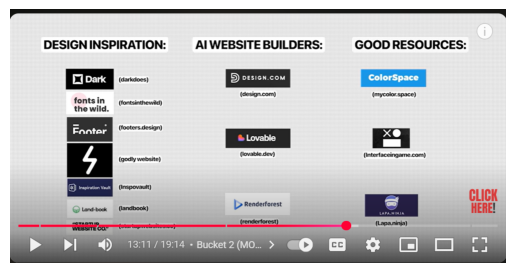

In [ ]:
# Write your code here to display img_array
img_array.shape
plt.imshow(img_array)
plt.axis("off")

## Image Cropping

### Student Practice
Crop the **center 200x200 region** of your image (not a random corner — think about how to calculate the center offset from `img_array.shape`), store it in a variable called `crop`, and display it.


(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

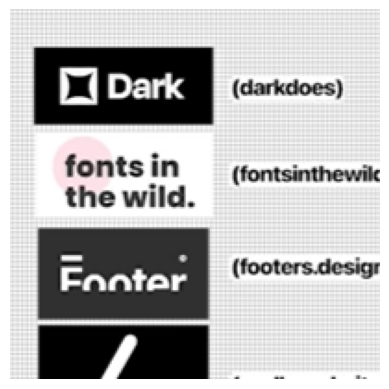

In [ ]:
# Write your cropping code here
crop = img_array[100:300, 100:300]
plt.imshow(crop)
plt.axis("off")


### Quick demo: showing multiple images side by side

You'll want to display more than one image at once in the tasks below (e.g. two flipped versions, or three RGB channels). `plt.subplots()` lets you do this in a grid. Study this small example, then reuse the pattern.


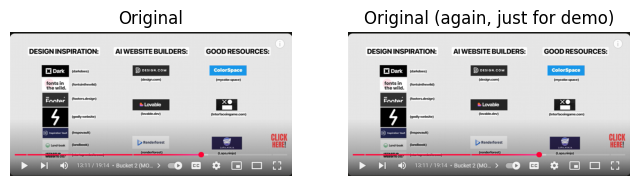

In [ ]:
# Demo: showing 2 plots side by side using plt.subplots
fig, axes = plt.subplots(1, 2, figsize=(8,4))

axes[0].imshow(img_array)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_array)
axes[1].set_title("Original (again, just for demo)")
axes[1].axis("off")

plt.show()


## Image Flipping

### Student Practice
Produce and display both a vertical flip and a horizontal flip of your image using slicing (`[::-1]`), without using any built-in flip function.


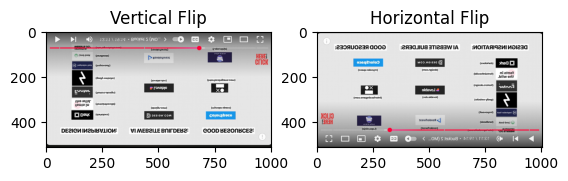

In [ ]:
import matplotlib.pyplot as plt

v = img_array[::-1]
h = img_array[:, ::-1]

plt.subplot(1,2,1)
plt.imshow(v)
plt.title("Vertical Flip")

plt.subplot(1,2,2)
plt.imshow(h)
plt.title("Horizontal Flip")

plt.show()

## RGB Channel Analysis

RGB channels:

- 0 - Red
- 1 - Green
- 2 - Blue

### Student Practice
Extract the red, green, and blue channels separately, and display each one using `plt.imshow(channel, cmap="gray")` so you can see which areas of the image are strongest in each color.


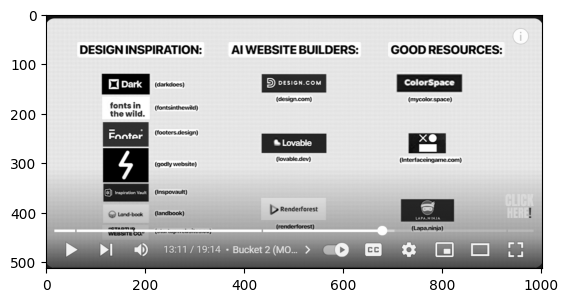

In [ ]:
# Write your RGB channel code here
red_channel = img_array[:, :, 0]
green_channel = img_array[:, :, 1]
blue_channel = img_array[:, :, 2]

plt.imshow(red_channel, cmap="gray")


## Brightness Analysis

### Student Practice
Calculate the average brightness of your image using `np.mean()`. Then calculate the average brightness of just the red channel, just the green channel, and just the blue channel. Which channel is brightest? Write your answer below the code.


In [ ]:
# Write your brightness code here
import numpy as np
print("Average brightness:", np.mean(img_array))
print("Red channel brightness:", np.mean(img_array[:, :, 0]))
print("Green channel brightness:", np.mean(img_array[:, :, 1]))
print("Blue channel brightness:", np.mean(img_array[:, :, 2]))


Average brightness: 204.22116010642537
Red channel brightness: 187.6029999669607
Green channel brightness: 186.37297658680876
Blue channel brightness: 187.90866387193196


*Your answer:* blue channel


## Thresholding

Convert the image into pure black-and-white using `np.where()`.

### Student Practice
1. Convert the image to grayscale by averaging the 3 channels (`axis=2`).
2. Use `np.where(gray > 128, 255, 0)` to create a binary (black/white) version.
3. Display the result.
4. Try a different threshold (e.g. 100 or 180) and observe how it changes the result.


(np.float64(-0.5), np.float64(1002.5), np.float64(512.5), np.float64(-0.5))

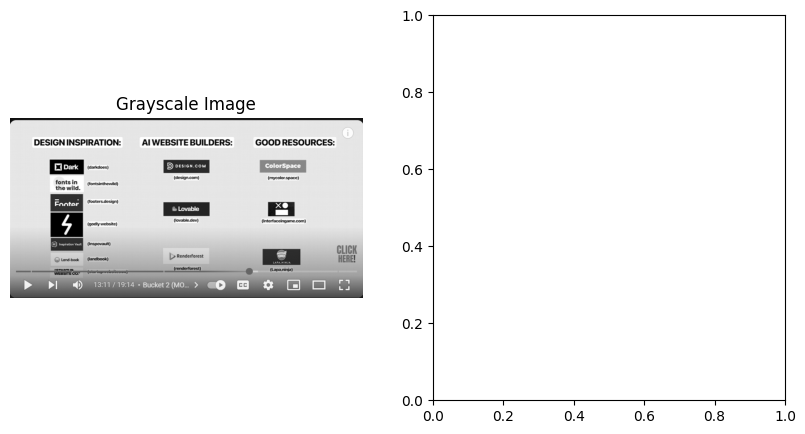

In [ ]:
gray_image = np.mean(img_array[:, :, :3], axis=2).astype(np.uint8)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_image, cmap='gray')
axes[0].set_title('Grayscale Image')
axes[0].axis('off')

In [ ]:
# Apply thresholding
threshold_value = 128
binary_image = np.where(gray_image > threshold_value, 255, 0).astype(np.uint8)

# Display the binary image
axes[1].imshow(binary_image, cmap='gray')
axes[1].set_title(f'Binary Image (Threshold > {threshold_value})')
axes[1].axis('off')
plt.show()

# Mini Project: Image Analyzer

Write a single program (you can reuse code from above) that prints/displays all of the following for your uploaded image, in order:

1. Image height, width, and number of channels
2. Average brightness (overall, and per channel)
3. The cropped center region
4. Both flipped versions (vertical and horizontal)
5. All 3 RGB channels shown separately
6. The thresholded (black/white) version

### Self-check before you submit
- [x] I wrote the code myself rather than only uncommenting given code
- [x] I can explain what every line does, not just that it runs
- [x] My image display uses `plt.axis("off")` and looks correct
- [x] I answered all reflection questions in my own words

## Reflection Questions

1. Why is NumPy faster than Python lists? (Refer back to your Part 1 answer — refine it if needed.)

NumPy is faster because it stores data efficiently and performs operations using optimized code instead of looping through each element in Python.

2. Explain broadcasting with an example of your own.

Broadcasting allows NumPy to perform operations on arrays of different but compatible shapes.

3. What does image shape `(512,512,3)` represent?

It means the image is 512 pixels high, 512 pixels wide, and has 3 color channels (RGB).

4. Why should we avoid printing complete image arrays?

Image arrays contain thousands or millions of values, so printing the whole array makes the output huge and difficult to read.

5. Explain RGB channels.

RGB stands for Red, Green, and Blue. Each pixel has three values representing the intensity of these three colors.

6. Where might you use this exact image-array workflow in a real machine learning project (e.g. what comes right before feeding an image into a CNN)?

This workflow can be used to load, resize, normalize, and convert images into NumPy arrays before feeding them into a CNN for image classification or other computer vision tasks.


Loaded Screenshot 2025-06-11 091927.png, shape: (513, 1003, 4)
--- Image Analysis Report ---
Height: 513, Width: 1003, Channels: 4

Overall average brightness: 187.29
Average Red channel brightness: 187.60
Average Green channel brightness: 186.37
Average Blue channel brightness: 187.91

--- Visualizing Image Transformations ---


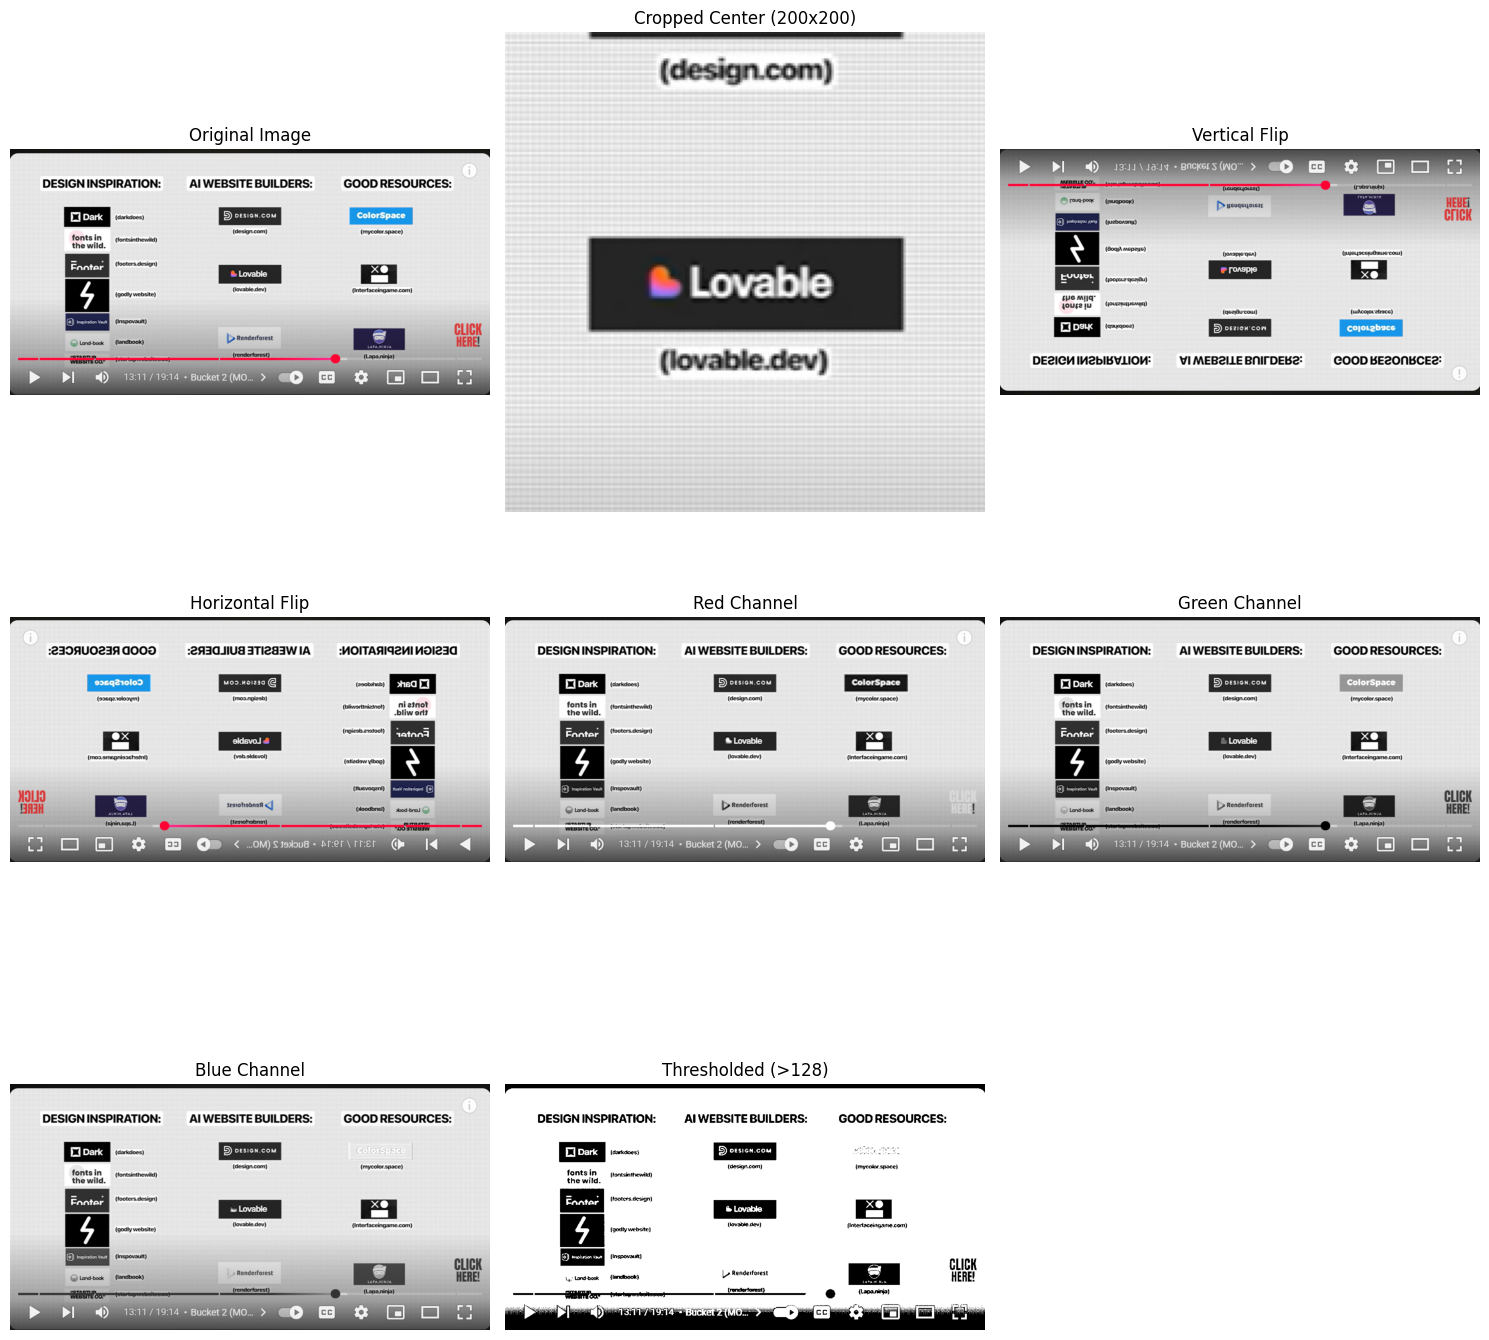

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

if not ('uploaded' in locals() and uploaded):
    print("Please upload your image file.")
    uploaded = files.upload()

if not uploaded:
    raise FileNotFoundError("No image loaded for analysis. Please upload a file.")

image_filename = next(iter(uploaded))
pil_image = Image.open(image_filename)
img_array = np.array(pil_image)
print(f"Loaded {image_filename}, shape: {img_array.shape}")

print("--- Image Analysis Report ---")

height, width = img_array.shape[0], img_array.shape[1]
channels = img_array.shape[2] if img_array.ndim == 3 else 1
print(f"Height: {height}, Width: {width}, Channels: {channels}")

is_color_image = (img_array.ndim == 3 and img_array.shape[2] >= 3)
img_for_brightness = img_array[:, :, :3] if (img_array.ndim == 3 and img_array.shape[2] == 4) else img_array
img_for_brightness = img_for_brightness.astype(np.float32)

overall_brightness = np.mean(img_for_brightness)
print(f"\nOverall average brightness: {overall_brightness:.2f}")

if is_color_image:
    print(f"Average Red channel brightness: {np.mean(img_for_brightness[:, :, 0]):.2f}")
    print(f"Average Green channel brightness: {np.mean(img_for_brightness[:, :, 1]):.2f}")
    print(f"Average Blue channel brightness: {np.mean(img_for_brightness[:, :, 2]):.2f}")
else:
    print("Image is grayscale, no separate RGB channel brightness reported.")

crop_size = 200
actual_crop_size = min(height, width, crop_size)
start_row = (height - actual_crop_size) // 2
end_row = start_row + actual_crop_size
start_col = (width - actual_crop_size) // 2
end_col = start_col + actual_crop_size
cropped_center = img_array[start_row:end_row, start_col:end_col]

flip_vertical = img_array[::-1, ...]
flip_horizontal = img_array[:, ::-1, ...]

red_channel_display = img_array[:, :, 0] if is_color_image else None
green_channel_display = img_array[:, :, 1] if is_color_image else None
blue_channel_display = img_array[:, :, 2] if is_color_image else None

gray_image = np.mean(img_for_brightness, axis=2).astype(np.uint8) if is_color_image else img_array.astype(np.uint8)
threshold_value = 128
binary_image = np.where(gray_image > threshold_value, 255, 0).astype(np.uint8)

print("\n--- Visualizing Image Transformations ---")

plot_items = [
    (img_array, "Original Image", None),
    (cropped_center, f"Cropped Center ({actual_crop_size}x{actual_crop_size})", None),
    (flip_vertical, "Vertical Flip", None),
    (flip_horizontal, "Horizontal Flip", None)
]

if is_color_image:
    plot_items.extend([
        (red_channel_display, "Red Channel", "gray"),
        (green_channel_display, "Green Channel", "gray"),
        (blue_channel_display, "Blue Channel", "gray")
    ])
else:
    print("\nImage is not a color image, skipping separate RGB channel display.")

plot_items.append((binary_image, f"Thresholded (>{threshold_value})", "gray"))

num_plots = len(plot_items)
rows = int(np.ceil(np.sqrt(num_plots)))
cols = int(np.ceil(num_plots / rows))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = axes.flatten()

for i, (image_data, title, cmap) in enumerate(plot_items):
    ax = axes[i]
    ax.imshow(image_data, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

for i in range(num_plots, len(axes)):
    axes[i].axis("off")
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Part 15: Text Analysis Using NumPy (NLP Track)

## Why this matters for ML/NLP

Before any NLP model (sentiment classifier, spam detector, chatbot) can process text, the text must be converted into numbers — this is called **vectorization**. NumPy arrays are the underlying data structure for almost every text representation: word counts, one-hot vectors, TF-IDF vectors, and even word embeddings are all just NumPy (or NumPy-like) arrays.

In this section, you'll build a small text analysis pipeline entirely with NumPy — no external NLP libraries — so you understand what's actually happening under the hood before you use libraries like `scikit-learn` or `nltk` later in the course.


## Step 1: From Text to Tokens

The first step in any NLP pipeline is **tokenization** — splitting text into individual words.

### Demonstration


In [ ]:
sentence = "NumPy makes numerical computing fast and NumPy makes arrays powerful"

# Basic tokenization: lowercase + split on spaces
tokens = sentence.lower().split()
print(tokens)


['numpy', 'makes', 'numerical', 'computing', 'fast', 'and', 'numpy', 'makes', 'arrays', 'powerful']


### Student Practice

Tokenize this sentence the same way: `"Data Science and Machine Learning use NumPy arrays every single day"`. Store the result in a variable called `tokens2`.


In [ ]:
# Write your answer here
sentence2 = "Data Science and Machine Learning use NumPy arrays every single day"
tokens2 = sentence2.lower().split()
print(tokens2)


['data', 'science', 'and', 'machine', 'learning', 'use', 'numpy', 'arrays', 'every', 'single', 'day']


## Step 2: Building a Vocabulary

A **vocabulary** is the set of all unique words across your text(s). We'll use `np.unique()` — the same function idea you used earlier for arrays of numbers, now applied to an array of words.


In [ ]:
tokens_array = np.array(tokens)
vocabulary = np.unique(tokens_array)
print("Vocabulary:", vocabulary)
print("Vocabulary size:", len(vocabulary))


Vocabulary: ['and' 'arrays' 'computing' 'fast' 'makes' 'numerical' 'numpy' 'powerful']
Vocabulary size: 8


### Student Practice

Build the vocabulary for `tokens2` from Step 1. How many unique words does it contain?


In [ ]:
# Write your answer here
tokens_array2 = np.array(tokens2)
vocabulary2 = np.unique(tokens_array2)
print("Vocabulary:", vocabulary2)
print("Vocabulary size:", len(vocabulary2))


Vocabulary: ['and' 'arrays' 'data' 'day' 'every' 'learning' 'machine' 'numpy'
 'science' 'single' 'use']
Vocabulary size: 11


## Step 3: Word Frequency Vector (Bag-of-Words)

A **bag-of-words** vector represents a sentence as an array of word counts, one count per vocabulary word — this ignores word order but captures *what* words appear and *how often*.

### Demonstration: build a word-count vector by hand using NumPy


In [ ]:
def bag_of_words_vector(tokens, vocabulary):
    # For each word in the vocabulary, count how many times it appears in tokens
    vector = np.array([np.sum(np.array(tokens) == word) for word in vocabulary])
    return vector

vec = bag_of_words_vector(tokens, vocabulary)
print(vocabulary)
print(vec)


['and' 'arrays' 'computing' 'fast' 'makes' 'numerical' 'numpy' 'powerful']
[1 1 1 1 2 1 2 1]


### Student Practice — predict then check

Before running, predict: which word(s) will have a count of 2 in the vector above? (Hint: look back at the original sentence — which word repeats?)

*Your prediction:*

Now build the bag-of-words vector for `tokens2` using its own vocabulary, and check your prediction concept applies the same way.


In [ ]:
# Write your answer here
vec2 = bag_of_words_vector(tokens2, vocabulary)
print(vocabulary)
print(vec2)


['and' 'arrays' 'computing' 'fast' 'makes' 'numerical' 'numpy' 'powerful']
[1 1 0 0 0 0 1 0]


## Step 4: Comparing Two Sentences (Cosine Similarity)

Once text is turned into number vectors, we can measure how *similar* two sentences are using **cosine similarity** — a formula you'll see constantly in NLP and recommendation systems:

$$\text{cosine similarity} = \frac{A \cdot B}{\|A\| \times \|B\|}$$

This measures the angle between two vectors, not their length — so it works even if one sentence is longer than another.

### Demonstration


In [ ]:
sentence_a = "machine learning uses numpy arrays"
sentence_b = "deep learning also uses numpy arrays heavily"

tokens_a = sentence_a.lower().split()
tokens_b = sentence_b.lower().split()

# Build a shared vocabulary from both sentences combined
combined_vocab = np.unique(np.array(tokens_a + tokens_b))

vec_a = bag_of_words_vector(tokens_a, combined_vocab)
vec_b = bag_of_words_vector(tokens_b, combined_vocab)

print("Vector A:", vec_a)
print("Vector B:", vec_b)

# Cosine similarity using NumPy dot product and norm
cosine_sim = np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))
print("Cosine similarity:", cosine_sim)


Vector A: [0 1 0 0 1 1 1 1]
Vector B: [1 1 1 1 1 0 1 1]
Cosine similarity: 0.6761234037828131


### Student Practice

Pick two sentences of your own (write them below) — one pair that should be *similar* in meaning/topic, and one pair that should be *very different*. Compute the cosine similarity for both pairs and confirm your intuition matches the numbers.


In [ ]:
# Write your answer here

sentence_a_similar = "walking is good for health"
sentence_b_similar = "She is walking"

tokens_a_similar = sentence_a_similar.lower().split()
tokens_b_similar = sentence_b_similar.lower().split()

combined_vocab_similar = np.unique(np.array(tokens_a_similar + tokens_b_similar))

vec_a_similar = bag_of_words_vector(tokens_a_similar, combined_vocab_similar)
vec_b_similar = bag_of_words_vector(tokens_b_similar, combined_vocab_similar)

print("--- Similar Sentences Pair ---")
print("Sentence A:", sentence_a_similar)
print("Sentence B:", sentence_b_similar)
print("Vector A (similar):", vec_a_similar)
print("Vector B (similar):", vec_b_similar)
cosine_sim_similar = np.dot(vec_a_similar, vec_b_similar) / (np.linalg.norm(vec_a_similar) * np.linalg.norm(vec_b_similar))
print("Cosine similarity (similar):", cosine_sim_similar)
print("-" * 30)

# --- Pair 2: Very Different Sentences (example) ---
sentence_a_different = "the cat sat on the mat"
sentence_b_different = "jupiter is the largest planet"

tokens_a_different = sentence_a_different.lower().split()
tokens_b_different = sentence_b_different.lower().split()

combined_vocab_different = np.unique(np.array(tokens_a_different + tokens_b_different))

vec_a_different = bag_of_words_vector(tokens_a_different, combined_vocab_different)
vec_b_different = bag_of_words_vector(tokens_b_different, combined_vocab_different)

print("Sentence A:", sentence_a_different)
print("Sentence B:", sentence_b_different)
print("Vector A (different):", vec_a_different)
print("Vector B (different):", vec_b_different)
cosine_sim_different = np.dot(vec_a_different, vec_b_different) / (np.linalg.norm(vec_a_different) * np.linalg.norm(vec_b_different))
print("Cosine similarity (different):", cosine_sim_different)

--- Similar Sentences Pair ---
Sentence A: walking is good for health
Sentence B: She is walking
Vector A (similar): [1 1 1 1 0 1]
Vector B (similar): [0 0 0 1 1 1]
Cosine similarity (similar): 0.5163977794943222
------------------------------
Sentence A: the cat sat on the mat
Sentence B: jupiter is the largest planet
Vector A (different): [1 0 0 0 1 1 0 1 2]
Vector B (different): [0 1 1 1 0 0 1 0 1]
Cosine similarity (different): 0.31622776601683794


**Reflection:** In your own words, why does cosine similarity give a value close to 1 for similar sentences and close to 0 for unrelated sentences? What would a `cosine similarity` of exactly 1 mean about two vectors?

*Your answer:* Cosine similarity checks the angle between two vectors. Similar sentences have vectors pointing in almost the same direction, so the value is close to 1. Unrelated sentences point in different directions, so the value is closer to 0.


## Step 5: Most Frequent Words

### Student Practice

Take any paragraph of your choice (3-4 sentences, write it below as a string). Then:
1. Tokenize it.
2. Build its vocabulary and word-count vector (reuse `bag_of_words_vector`).
3. Use NumPy to find and print the **top 3 most frequent words** (hint: look at sorting — `np.argsort()` sorts indices by value, and slicing with `[::-1]` reverses order).


In [ ]:
paragraph = "Artificial intelligence is rapidly transforming various industries. Machine learning, a subset of AI, enables systems to learn from data without explicit programming. Deep learning, an even more advanced technique, uses neural networks with many layers to process complex patterns. These technologies are at the forefront of innovation, driving advancements in fields from healthcare to finance."
paragraph_tokens = paragraph.lower().split()
print("Tokens:", paragraph_tokens)
paragraph_vocabulary = np.unique(np.array(paragraph_tokens))
print("\nVocabulary:", paragraph_vocabulary)
paragraph_word_vector = bag_of_words_vector(paragraph_tokens, paragraph_vocabulary)
print("\nWord Count Vector:", paragraph_word_vector)
sorted_indices = np.argsort(paragraph_word_vector)
top_3_indices = sorted_indices[::-1][:3]
top_3_words = paragraph_vocabulary[top_3_indices]
top_3_counts = paragraph_word_vector[top_3_indices]
print("\nTop 3 most frequent words:")
for i in range(len(top_3_words)):
    print(f"{i+1}. '{top_3_words[i]}' (count: {top_3_counts[i]})")

Tokens: ['artificial', 'intelligence', 'is', 'rapidly', 'transforming', 'various', 'industries.', 'machine', 'learning,', 'a', 'subset', 'of', 'ai,', 'enables', 'systems', 'to', 'learn', 'from', 'data', 'without', 'explicit', 'programming.', 'deep', 'learning,', 'an', 'even', 'more', 'advanced', 'technique,', 'uses', 'neural', 'networks', 'with', 'many', 'layers', 'to', 'process', 'complex', 'patterns.', 'these', 'technologies', 'are', 'at', 'the', 'forefront', 'of', 'innovation,', 'driving', 'advancements', 'in', 'fields', 'from', 'healthcare', 'to', 'finance.']

Vocabulary: ['a' 'advanced' 'advancements' 'ai,' 'an' 'are' 'artificial' 'at'
 'complex' 'data' 'deep' 'driving' 'enables' 'even' 'explicit' 'fields'
 'finance.' 'forefront' 'from' 'healthcare' 'in' 'industries.'
 'innovation,' 'intelligence' 'is' 'layers' 'learn' 'learning,' 'machine'
 'many' 'more' 'networks' 'neural' 'of' 'patterns.' 'process'
 'programming.' 'rapidly' 'subset' 'systems' 'technique,' 'technologies'
 'the' 

# Mini Project: Simple Text Similarity Checker (NLP Track)

Build a small program that:

1. Takes **three** short sentences of your choice (write them as strings).
2. Tokenizes all three and builds one shared vocabulary across all of them.
3. Converts each sentence into a bag-of-words vector using that shared vocabulary.
4. Computes cosine similarity between every pair of sentences (3 pairs total: 1-2, 1-3, 2-3).
5. Prints which two sentences are the **most similar** to each other, based on the highest cosine similarity score.

### Self-check before you submit
- [x] I wrote my own three sentences (not copied from the notebook)
- [x] I can explain what a bag-of-words vector represents, in my own words
- [x] I can explain why cosine similarity works even when sentences are different lengths
- [x] My program correctly identifies and prints the most similar pair

## Reflection Questions (NLP Track)

1. Why do we need to convert text into numbers before a machine learning model can use it?

Machine learning models work with numbers, so text needs to be converted into numerical values first.


2. What information does a bag-of-words vector *lose* about the original sentence? (Hint: think about what `split()` and counting alone doesn't capture.)

It loses the word order and context of the sentence. For example, “dog bites man” and “man bites dog” can look very similar.


3. Why might cosine similarity be a better similarity measure than simply comparing raw word-count differences?

Cosine similarity compares the direction of the vectors, so it focuses more on how similar the word patterns are rather than just the difference in word counts.


4. Name one real-world application that likely uses something like this text-vectorization + similarity approach (e.g. search engines, plagiarism checkers, recommendation systems — pick one and explain briefly).

Search engines can use this approach to compare a user's search query with documents and find the ones containing similar words or meaning.


In [ ]:
import numpy as np

s1 = "the stars shine brightly in the night sky"
s2 = "astronomy is the study of celestial objects and stars"
s3 = "artificial intelligence models require large amounts of data"

tokens1, tokens2, tokens3 = s1.lower().split(), s2.lower().split(), s3.lower().split()
vocab = np.unique(tokens1 + tokens2 + tokens3)

def get_vec(tokens, vocab):
    return np.array([tokens.count(word) for word in vocab])

vec1 = get_vec(tokens1, vocab)
vec2 = get_vec(tokens2, vocab)
vec3 = get_vec(tokens3, vocab)

def cosine_sim(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

sim12 = cosine_sim(vec1, vec2)
sim13 = cosine_sim(vec1, vec3)
sim23 = cosine_sim(vec2, vec3)

print(f"Similarity (1-2): {sim12:.4f}")
print(f"Similarity (1-3): {sim13:.4f}")
print(f"Similarity (2-3): {sim23:.4f}")

scores = {(1,2): sim12, (1,3): sim13, (2,3): sim23}
best_pair = max(scores, key=scores.get)
print(f"\nThe most similar sentences are {best_pair[0]} and {best_pair[1]} with a score of {scores[best_pair]:.4f}.")

Similarity (1-2): 0.3162
Similarity (1-3): 0.0000
Similarity (2-3): 0.1179

The most similar sentences are 1 and 2 with a score of 0.3162.
